Aiden Nachtmann - 50580008
## Noise within Images

Image noise is a random, unwanted distortion in the brightness of color of image. Noise appears in some extent in every image and can be caused by imperfection in cameras, random light fluctuations, errors during image recording, storage and transmission, etc. One variation of noise is called salt and pepper noise. This is when certain pixels of an image are replaced with either black or white pixels, causing the image to look like it has salt and pepper flakes on it. 

Throughout this report we will be working with grayscale images and explore a cycle of noise. That is, we will be adding noise to an image and then go through ways to restore the image using various filters. We will explore the difference between a mean vs median filter and further build upon new ways to restore our image. 

To continue let us import our python modules NumPy and Matplotlib to allow for precise computal means.

In [28]:
import numpy as np
import matplotlib.pyplot as plt

Using matplotlibs `plt.imread` function, we can read in our image as a 3D array represented by $(m,n,3)$ where $m,n$ gives the size of our array and we have $3$ RGB color channels.

In [29]:
motorbike = plt.imread('motorbike.png') # reads greyscaled image what we want

(np.float64(-0.5), np.float64(639.5), np.float64(551.5), np.float64(-0.5))

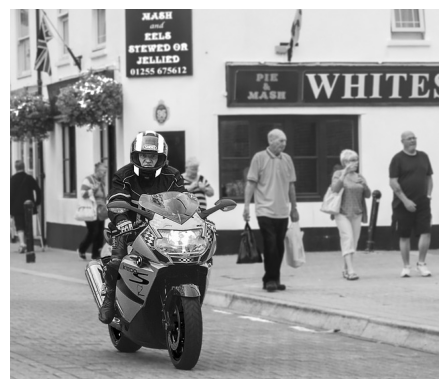

In [30]:
plt.imshow(motorbike)                   # displays image
plt.axis('off')

As we previously stated, we imported `motorbike` as a our starting image. We also said that we want to work specifically with grayscaled images. That is, an image is considered grayscale when every composing pixel of that image are only shades of gray. 
>Note: A shade of gray is produced when all three RGB channels for a pixel are the same integer in the range of 0 - 256. As you start at 0 and move towards 256, you go from black pixels to white pixels in a gray-scale, hence the name greyscale.
>
Since `mnotorbike` was imported as a 3D array it still contains RGB color channels. To ensure that our image is grayscaled, we can average the RGB values at each pixel. We do this using Numpy's `np.mean` function, utilizing the `axis` argument to specifically sort through the color channels. We then display image resulting from the averaged array calling to `plt.imshow` with the parameters of `cmap='gray'`, `vmin=0`, and `vmax=1`. More on these parameters will soon follow. 

We can now display our image with averaged RGB channels, `gray_motorbike`.

(np.float64(-0.5), np.float64(639.5), np.float64(551.5), np.float64(-0.5))

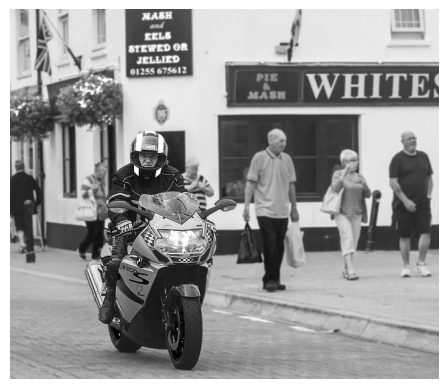

In [31]:
gray_motorbike = np.mean(motorbike, axis = 2)

plt.imshow(gray_motorbike, cmap='gray', vmin=0,vmax=1)
plt.axis('off')

### Array Size and Display Parameters
One property of greyscale images is that we can represent them, in our case grayscaled image `gray_motorbike`, as a 2D, `(m,n)` array rather than a 3D, `(m,n,3)` array without loss of information. This is due to the fact that RGB values represented by that last triple in a 3D array of a given *grayscaled* image are all equal. As previously seen, you can achieve this by taking an average of all RGB values for each pixel in an image. 

In order to display these images, we need to take into consideration that matplotlib's `plt.imshow` function defaults to the `viridis` color map. This color map represents color values over a range of dark blue to bright yellow. To avoid this, we can override the default setting by calling the same function `plt.imshow`, and then add the following parameters:
> `cmap = 'gray'`. This sets the color map of our image to `gray`, switching from `viridis`. <br>
> `vmin = 0`. This defines our minimum value of the data range for our desired gray colormap. <br>
> `vmax = 1`. This defines our maximum value of the data range for our desired gray colormap. <br>
>
Since we are using float data type in our array, we only need to work within the range [0,1).

### `imshow_gray(img)`
Having to type the parameters for an image to be greyscaled each time is a tedious task. We can easily tackle this obstacle by creating a function `imshow_gray(img)`. This function takes input of an image as `img` which plots said image in grayscale form using the previously defined parameters. 

In [32]:
def imshow_gray(img):                                   # takes input variable img 
    plt.imshow(img, cmap = 'gray', vmin = 0, vmax = 1)  # sets parameters
    plt.axis('off')

We can test that this function displays our image `gray_motorbike` in grayscale format as follows:

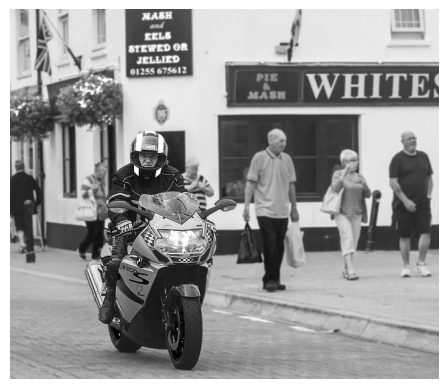

In [33]:
imshow_gray(gray_motorbike)

As we can seem, `gray_motorbike` was successfully displayed in grayscale format. We will call to this function throughout the remainder of the report when we need to display our grayscaled image motorbike or a filtered version of it.

## Injecting Noise
Recall that as we explore noise, we will be seeing ways to add noise to an image, namely salt and pepper noise. Now that we have a grayscaled image as 2D array, let us add said noise to it. In order to preserve the orginal image array of `gray_motorbike`, we create a copy of of this array and define it as `noisy_img`. It is this copy of the array as an image that we will be adding the salt and pepper noise to. We use numpy's `.copy()` function so that the changes made to `noisy_img` do not change the original `gray_motorbike` array.

In [34]:
noisy_img = gray_motorbike.copy()

To randomly select pixels of the `noisy_img` array to add salt and pepper noise, we use numpy's `np.random.random` function. This works as follows:
> `np.random.random()` will return a randomly selected float in the interval [0,1). <br>
> `np.random.random(shape)` will return an array with shape `shape`, where each entry contains a randomly selected float in the interval [0,1)
>
In our case, the interval [0,1) works like a 0 to 100 percent scale where each pixel is assigned a random float value between 0 and 1 which resembles a percentage from 0 to 100. 
> Note(s):
> - We will interchangeably use 'floats' to describe float integer values. These 'floats' resemble integers such as `0.661`, `0.991` or `0.001`. <br>
> - We will interchangeably use 'noise' to describe salt and pepper noise.

### `sp_noise(img, noise)`
To add salt and pepper noise to our image, we created the function `sp_noise(img, noise)`. The input `img` is the original image which we want to add noise to, and the input `noise` represents the total percent of pixels that will be replaced with noise. 
First, we store the shape of the image using its rows and columns. We store these as `nrows` and `ncols`. We then make a copy of our image, called `noisy_img` using Numpy's `.copy()` function. This is so we can modify the copy of our image while preserving the original,.We used Numpy's `np.random.random` function, to create a `random_array`, which each entries in this array is a random float between 0 and 1. The floats from these arrays are used to decide which pixels will be replaced by noise. 

We are using input `noise` as follows:
> Let $n$ denote our desired percent of pixels to be replaced, aka `noise` . <br>
> Since we are working with float values, we take the top $\frac{0.n}{2}$% of pixels in our image and the bottom $\frac{0.n}{2}$% of pixels in our image to be evenly replaced with noise. <br>
> That is, we select the top percent of pixels with floats greater than $\frac{1 - 0.n}{2}$ to be replaced with salt noise (a white pixel) by setting that float equal to one. We then take the bottom percent of pixels with floats less than $\frac{0.n}{2}$ to be replaced with pepper noise (a black pixel) by setting that float equal to zero.<br>
> We divide $0.n$ by two because the noise is split into two parts: white pixels (salt noise) and black pixels (pepper noise). We want an even amount of both. <br>
>
This function then sorts through every pixel in our image, and sorts every random float in `random_array` and applies the noise to our image by previous stated means.

In [35]:
def sp_noise(img, noise):                            # defines function with input img, noise
    nrows, ncols = img.shape                         # takes row and column size of input image
    noisy_img = img.copy()                           # creates a copy of our image to preserve orginal array
    random_array = np.random.random((nrows, ncols))
    for row in range(nrows):                         # sorts through every row in our image
        for col in range(ncols):                     # sorts through every column in our image
            if random_array[row, col] > 1 - (noise/100)/2:       # if random float is less than half of cutoff float
                noisy_img[row, col] = 1              # set half of pixels to be placed by white pixels
            if random_array[row, col] < (noise/100)/2:   # if rnadom float is less than half of cutoff float
                noisy_img[row, col] = 0              # set half of pixels to be replaced by black pixels
    return noisy_img                                 # returns distored image

We can now test our function. Let us choose our greyscale copy of `motorobike`, `noisy_img` and apply 20% noise. We call to our function and store the outut as a variable to plot:

In [36]:
noisy_motorbike = (sp_noise(noisy_img, 20))

We can now call to our `imshow_gray(img)` function to plot our image with noise:

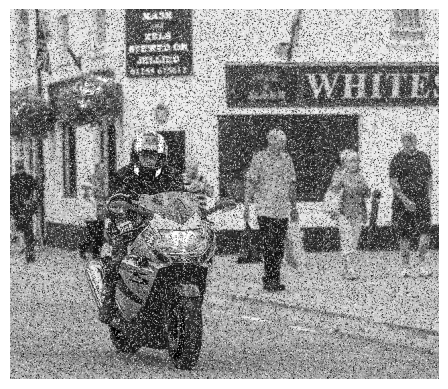

In [37]:
imshow_gray(noisy_motorbike)

As we can see, our image now displays with our selected amount of noise being 20%. We can now move forward and see how we may fix the noise added to an image by applying following filters to our image `noisy_img`.

## Image Denoising
Through the remainder of this report, we focus on ways to remove noise from our image, `noisy_img`. As a reminder this image is a copy of our original grayscaled image `motorbike` and contains an even mix of 20% salt and pepper noise. To remove the noise, we will be applying two main filters: `mean_filter_edge` and `median_filter_edge`.
> `mean_filter_edge` replaces all pixels with the average value of the pixels surrounding it with an array of a certain grid size.<br>
> `median_filter_edge` replaces all pixels with the median value of the pixels surrounding it an array of a certain grid size. <br>

Then, we will move onto a filter of our own creation to fix the noise in `noisy_img`.  <br>

To motivate why these filters specify contain **"edge"** in their title, let us dive into the principle of image padding.

### Image Padding
Before we can remove the noise which we added to our image `motorbike`, we need to understanding one key feature about the filters which do such task. We need to take into consideration the case that some pixels that were randomly chosen to add noise to are on the edge of our image. This is important because for the pixels with noise in the middle of our image, we can center an $s$ by $s$ grid around each of those pixels. In the case of pixels with noise on the edge of our image, parts of that surrounding grid will fall outside the image. 

To handle edge pixels, we created a function `get_padded_img`, which takes inputs of an image as `img` and a pad size as `pad`. This function generates a padded version of the image. By these inputs, this function takes the shape of `img` as `nrows` and `ncols` to copy the size of rows and colunms.  Using the input `pad` we are then define a new array, `padded_img`, which adds addtional rows and columns of zeros to the top and bottom, left and right of our array with shape of `nrows` and `ncols`. The amount of added rows and columns are determined by input `pad`. Then, our original image is placed in the center of our new, larger array. This padding allows us to apply mean or median filters on edge pixels, since now every original pixel has new values surrounding it.

In [38]:
def get_padded_img(img, pad):                                # takes input of image and size of pad
    nrows, ncols = img.shape                                 # takes rows and columns of input img
    padded_img = np.zeros((nrows + 2*pad, ncols + 2*pad))    # adds our desired amount of padding to the image
    padded_img[pad:-pad, pad:-pad] = img                     # set the img array into the center of padded_img
    return padded_img

### Mean Filter 
As our first method of reducing noise in an image, we create a function called `mean_filter_edge(img,pad)` which takes inputs of an image as `img` and of pad size as `pad`. This function takes `img` and replaces every pixel in that image with the average value of pixels in a grid surrounding every pixel. The input `pad` is what controls the size of this grid. 
> For example:
> - If we had input `pad` = 1, then would expand out by one pixel in every direction, creating a 3x3 grid surrounding said pixel. <br>
> - If we had input `pad` = 2, then we would exand out by two pixels in every direction, creating a 5x5 grid surround said pixel.

Before we can apply this filter, we create a copy of our input image called `mean_filtered_img`. This allows us to apply filters to the copy of our original image of input. We also create `padded_img` which is an array that adds extra rows and columns around the image so that edge pixels can still be filtered.

For every pixel position, denoted by `(i,j)`, the function will create a square grid from the our padded image. That is, the slice `padded_img[i-pad+pad:i+pad+1+pad, j-pad+pad:j+pad+1+pad]` represents a grid centered around every corresponding pixel from the original image. This grid shifts our image inward by `pad` amount of rows and columns. This shift is what lets us take surrounding float values to calculate the mean for pixels in the edge of `noisy_img`. To take the mean, we use numpy's `np.mean` which replaces the original pixels with the average of its neighboring pixels.

In [39]:
def mean_filter_edge(img, pad):                         # defines function
    mean_filtered_img = img.copy()                      # creates copy of image to preserve original array
    nrows, ncols = img.shape                            # takes shape of image by rows and columns to sort through
    padded_img = get_padded_img(img, pad)               # defines larger, padded array
    for i in range(nrows):                              # sorts through rows 
        for j in range(ncols):                          # sorts through columns
            grid = padded_img[i-pad+pad:i+pad+1+pad, j-pad+pad:j+pad+1+pad] # this is the grid centered around every pixel
            mean_filtered_img[i,j] = np.mean(grid)      # takes the mean of the pixels surrounding any pixel in a pad by pad grid
    return mean_filtered_img                            # returns to keep the modified version.

Let us attempt to use the `man_filter_edge` function on our image with noise `noisy_img`, using a pad size of 2. We store the output as variable `mean_filter_edge_img` so that we can display it using our `imshow_gray` function to ensure it is in greyscaled format.

In [40]:
mean_filter_edge_img = mean_filter_edge(noisy_img, 2) # saves output of mean filter to be plotted

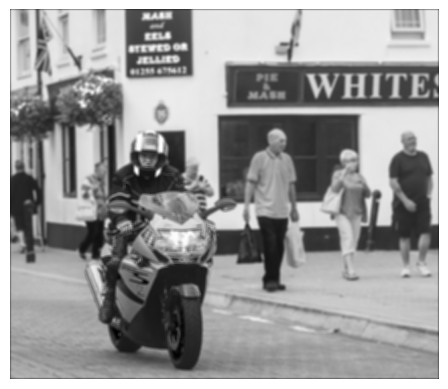

In [41]:
imshow_gray(mean_filter_edge_img)                     # plots output of mean filter using previously defined functions

As we can see, after applying the mean filter, much of the salt and pepper noise in the image is reduced. We can makes some notes that the image is now noticeably blurred because each pixel is now an average of its surrounding values from the image with noise. This output tells us that the mean filter allows us to smooth noise within an image, but it smooths the details of an image as well.

### Median Filter
For our second method of reducing noise, we create a function called `median_filter_edge(img,pad)`. This function is the exact same of our mean filter, `mean_filter_edge`, with the exception that we are taking the median of surrounding floats for every pixel in an image with noise. It takes inputs of an image as `img` and a pad size as `pad`. It then sorts through every pixel in the image with noise.
> Note: The median value is the value that lies in the center most position of an ordered list of floats. <br>

For every pixel position, denoted by `(i,j)`, the function will create a square grid from the our padded image. That is, the slice `padded_img[i-pad+pad:i+pad+1+pad, j-pad+pad:j+pad+1+pad]` represents a grid centered around every corresponding pixel from the original image. This grid shifts our image inward by `pad` amount of rows and columns. This shift is what lets us take surrounding float values to calculate the mean for pixels in the edge of `noisy_img`. To take the mean, we use numpy's `np.mean` which replaces the original pixels with the average of its neighboring pixels.

The biggest difference between the applications of the mean filter and median median is that the median value of the surrounding floats should be floats that resemble the color of our original array. This is because salt and peper noise are the extremes of floats, to which the median tends to be less effected by these values. Therefore, the median filter can noise while preserving more detail.

In [42]:
def median_filter_edge(img, pad):             # defines function
    median_filtered_img = img.copy()          # creates a copy of input to preserve original array
    nrows, ncols = img.shape                  # takes shape of image as rows and columns to be sorted through
    padded_img = get_padded_img(img, pad)     # defines larger, padded array
    for i in range(nrows):                    # sorts through rows
        for j in range(ncols):                # sorts through columns
            grid = padded_img[i-pad+pad:i+pad+1+pad, j-pad+pad:j+pad+1+pad] # grid centerd around every pixel in size determined by pad
            median_filtered_img[i,j] = np.median(grid) # uses numpy to calculate the median of the surroundig pixels
    return median_filtered_img                # returns to keep modified version.

Let us test our new filter `median_filter_edge` on our image of `motorbike` with noise, `noisy_img`, using a pad size of 2. We store the output of this function with these inputs as `median_filter_edge_img` so that we can plot it using our previously defined function `imshow_gray`.

In [43]:
median_filter_edge_img = median_filter_edge(noisy_img, 2) # saves output of function as variable

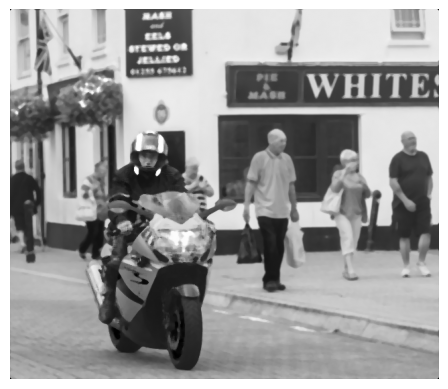

In [44]:
imshow_gray(median_filter_edge_img)                       # plots output of function as variable with grayscaled parameters

As we can see, the same image `noisy_img` how has had its noise significally reduced while also improving the quality to a greater amount than previously seen via the use of `mean_filter_edge`. This leads us into comparing and contrasting these functions and pad sizes as following:

## Observations between Mean and Median filters

We observe that the median filter works better for reducing salt and pepper noise than the mean filter. This is because the salt and pepper noise exists within extreme low or high floats. The mean is pulled from the grid of size `pad` surrounding every pixel in our image, and since those pixels with noise that are being filtered are from extremes, they average causes blurring as a result. So we can see that the median filter is less affected by these extreme floats because it chooses the middle value in the grid rather than the average. As a result we can see that the median filter does a better job and reducing noise and preserving detail. We can define two outputs of similar inputs for both mean and median filters as follows:

In [46]:
mean_filter_edge_img = mean_filter_edge(noisy_img, 2)       # saves output of mean filter for noisy image with pad size 2 
median_filter_edge_img = median_filter_edge(noisy_img, 2)   # saves output of median filter for noisy image with pad size 2 

We can now plot these outputs for the mean and median filters using our prior `imshow_gray` function:

Text(0.5, 1.0, 'Median Filter, pad = 2')

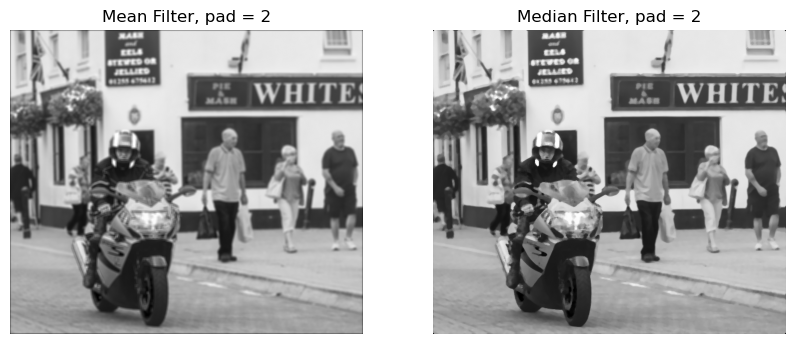

In [47]:
plt.figure(figsize=(10, 4))
plt.axis('off')

plt.subplot(1, 2, 1)
imshow_gray(mean_filter_edge_img)
plt.title('Mean Filter, pad = 2')

plt.subplot(1, 2, 2)
imshow_gray(median_filter_edge_img)
plt.title('Median Filter, pad = 2')

We can see that for the pad size of 2, the median filter does a better job than mean filter in reducing noise and preserving detail. Lets now explore what happens as a result of an increaseing value of `pad`. We can define increasing pad sizes to showcase an the difference as follows:

In [48]:
median_pad1 = median_filter_edge(noisy_img, 1)
median_pad2 = median_filter_edge(noisy_img, 2)
median_pad3 = median_filter_edge(noisy_img, 5)
median_pad4 = median_filter_edge(noisy_img, 10)

Let us now plot these increased pad sixes for our median filter:

Text(0.5, 1.0, 'Median Filter, pad = 10')

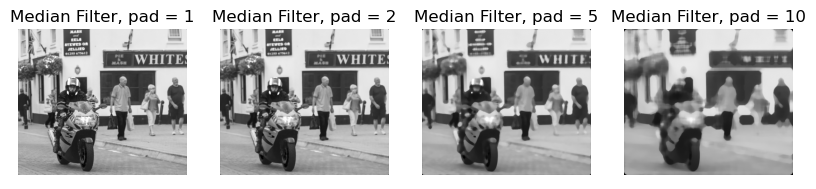

In [59]:
plt.figure(figsize=(10, 2))
plt.axis('off')

plt.subplot(1, 4, 1)
imshow_gray(median_pad1)
plt.title('Median Filter, pad = 1')

plt.subplot(1, 4, 2)
imshow_gray(median_pad2)
plt.title('Median Filter, pad = 2')

plt.subplot(1, 4, 3)
imshow_gray(median_pad3)
plt.title('Median Filter, pad = 5')

plt.subplot(1, 4, 4)
imshow_gray(median_pad4)
plt.title('Median Filter, pad = 10')


As our pad size increases, the filter uses a larger surrounding grid. This helps us reduce more noise because each pixel has more surrounding pixels its being compared to, so there is more data for the filters to work with. Thus, we are left with more accurate images in an increasing pad size. However, we must see that increasing `pad` also smooths out the image more, so the details are not as preserved. Therefore, a larger pad size can reduce noise but lose detail as it increases.

Lastly, let us explore the case of an increasing noise level. We will define different noise levels for our image `noisy_img` to be filted through `median_filter_edge` as follows:

In [60]:
noise10 = sp_noise(gray_motorbike.copy(), 10)  # preserves 10 percent noise to a copy of grey motorbike to preserve original array
noise30 = sp_noise(gray_motorbike.copy(), 30)  # preserves 30 percent noise to a copy of grey motorbike to preserve original array
noise50 = sp_noise(gray_motorbike.copy(), 50)  # preserves 50 percent noise to a copy of grey motorbike to preserve original array

We can then apply the filter `median_filter_edge` to these these different noise levels. We will keep the pad size 2 for each noise level to focus on the noise difference. We do this as storing the output of calling `median_filter_edge` to each noise level as follows:

In [61]:
median_noise10 = median_filter_edge(noise10, 2)  # saves output of filtering noisy_img with 10% noise with our median filter
median_noise30 = median_filter_edge(noise30, 2)  # saves output of filtering noisy_img with 30% noise with our median filter
median_noise50 = median_filter_edge(noise50, 2)  # saves output of filtering noisy_img with 50% noise with our median filter

Now, we can configure our plots to display the difference in increasing noise levels:

Text(0.5, 1.0, '50% noise, Median Filter, pad = 2')

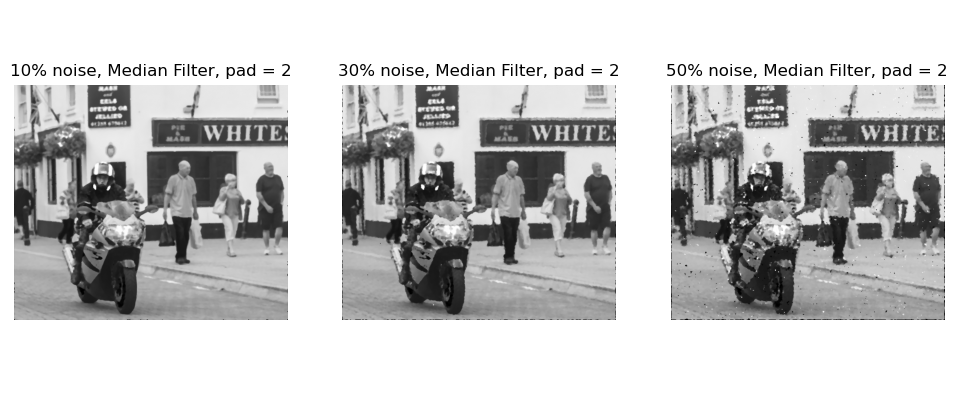

In [63]:
plt.figure(figsize=(12, 5))
plt.axis('off')

plt.subplot(1, 3, 1)
imshow_gray(median_noise10)
plt.title('10% noise, Median Filter, pad = 2')

plt.subplot(1, 3, 2)
imshow_gray(median_noise30)
plt.title('30% noise, Median Filter, pad = 2')

plt.subplot(1, 3, 3)
imshow_gray(median_noise50)
plt.title('50% noise, Median Filter, pad = 2')

As our noise level increases, the image becomes harder to restore. With an extensive amount of pixels with onoise, each filtering grid has a higher change of containing many white or black pixels. This will make it harder for the filer reduce noise to the original image. Even though we've seen that the median filter does a better job at reducing noise and preserving detail than the mean filter, the high noise levels still challnge our function and loss of detail is still transparent.

### `fix_filter_edge(img, pad)`
We create a filter of our own, called `fix_filter_edge(img,pad)`. This particular function takes input of an image as `img` and a pad size as `pad`. The purpose of this function is to improve the remaining noise along the outer rows and columns of our image after it had passed through a previous filter function. Instead of adding additional padding as we did in our earlier functions, this function only uses pixels that already exist within our image. Our `pad` input lets us control how far the grid goes in any direction. For example:
> If `pad` = 1 then the function stretches out the grid 1 pixel in all directions creating a $3$ by $3$ grid around each pixel. <br>
> If `pad` = 2 then the function strerches out the grid 2 pixels in all directions creating a $5$ by $5$ grid around each pixel.

Certain to this function, if any part of the pad centered around any pixel is outside our image, we shrink the pad size down so that it begins right at the first row or column (index 0). This function then replaces the edge pixels with the median value of of the surrounding pixels in the pad that are within the image. This allows the edge pixels to be filtetered again, without calculating within extra padding. This will result in smoothing the outer rows and columns out and fixing any imperfections.

By the statement: `if i < pad or i >= nrows - pad or j < pad or j >= ncols - pad:`, we are able to set conditions for a pixel to be considered an edge pixel. For every pair $(i,j)$ which is sorted through the columns and rows:

> - If the pixel is in the top outer rows we have: `i < pad`. That is the the row is less than our pad size. <br>
> - If the pixel is in the bottom outer rows, we have :`i >= nrows - pad` . That is the the row is greater than or equal to the amount of rows minus our pad size, strictly matching the pixels within our image. <br>
> - If the pixel is the left outer column, we have: `j < pad`. That is, our column is less than our pad size. <br>
> - If the pixel is in the right outer column, we have `j >= ncols - pad`. That is the column is greater than our equal to the amount of colummns minus our pad size, strictly matching the pixels within our image. <br>

We then set our starting and ending indicies for each $i,j$ entry in our rows and columns. These are defined by `row_start`, `row_end`, `col_start`, `col_end`. This is how we shape the grid around each pixel. We then set the coditions to keep all indicies within our image, setting the starting row and column indicies to their first position, index 0, and setting the ending row and column indicies to their last positions, nrows nad ncols. We then take define a `grid` as a slice of our indicies which is what selects only pixels that surround edge pixels but within the image. We when then replace all edge pixels with the median of their neighboring pixels in this grid of indicies. Lastly, we return back to our image `fixed_filter_edge_img`, which is our image which has passed through the filter `fix_filter_edge`, so it has its outermost columns and rows of size `pad` ran through our median filter again,

In [67]:
def fix_filter_edge(img, pad):          # defines function
    nrows, ncols = img.shape            # takes shape of input as rows and columns to sort through
    fixed_filter_edge_img = img.copy()  # creates a copy of our input image to preserve original array
    for i in range(nrows):              # sorts through rows
        for j in range(ncols):          # sorts through columns
            if i < pad or i >= nrows - pad or j < pad or j >= ncols - pad: # defines how we can measure edge pixels

                row_start = i - pad     # starting indicie for all rows
                row_end = i + pad + 1   # ending indicie for all rows
                col_start = j - pad     # starting indicie for all columns
                col_end = j + pad + 1   # ending indicie for all columns

                if row_start < 0:       # keeps row_start inside the image
                    row_start = 0       # sets to first row position, index 0
                if row_end > nrows:     # keeps row_end inside the image
                    row_end = nrows     # sets to last row position, nrows
                if col_start < 0:       # keeps col_start inside the image
                    col_start = 0       # sets to first column position, index 0 
                if col_end > ncols:     # keeps col_end inside the image
                    col_end = ncols     # sets to last column position, ncols

                grid = img[row_start:row_end, col_start:col_end] # selects only pixels in our image that surround the edge pixel

                fixed_filter_edge_img[i, j] = np.median(grid)    # takes the median value of all pixels in our grid

    return fixed_filter_edge_img       # returns back to copy of image to preserve original array.

> Recall the following: `median_filter_edge_img = median_filter_edge(noisy_img, 2)` stores the output of median filter for noisy image with pad size 2. 

We can define the output of this function as a variable to be plotted. We call this variable `fixed_edge_img`. We are going to use input image of `median_filter_edge_img` which has already passed through the median filter, as well as a pad size of 2:

In [69]:
fixed_edge_img = fix_filter_edge(median_filter_edge_img, 2) # saves output of `fix_filter_edge` function

Now, we can configure plots to compare the output of median filter for `noisy_img` compared to that result being ran through our function `fix_filter_edge`:

Text(0.5, 1.0, 'Median Filter + Median Edge filter')

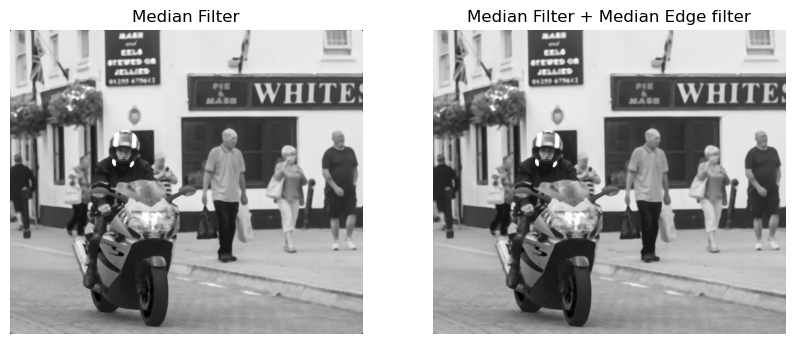

In [70]:
plt.figure(figsize = (10,4))
plt.axis('off')

plt.subplot(1,2,1)
imshow_gray(median_filter_edge_img)
plt.title('Median Filter')

plt.subplot(1,2,2)
imshow_gray(fixed_edge_img)
plt.title('Median Filter + Median Edge filter')

Comparing these two filters, we can see that the result from the function `fix_filter_edge` remains similar to the previously median filtered image, but the outer rows and columns are filtered again which allows for a smooth, yet detailed display. We did this avoiding artificial padding, yet keeping the edge pixels smooth. The change not extravagant because most of the image had already been hit by the median filter, so the final filter ensure that we pay more attention to the outermost pixels.

### Conclusion

Throughout this report, we added salt and pepper noise to a grayscaled image, and tested various methods to reduce that noise. We saw that the mean filter provided lackluster results compares to the median filter, and that filtering the outermost edges of an already median filtered image will result in the best noise reduction and quality preservation for the original image. Of course, this was within certain pad sizes and noise levels as we were also able to see that increasing the pad size or noise level by a sufficient amount will alter the outcome of the image after passing through a filter. That is, an increased pad size would allow for more noise to be reduced, yet more quality to be lost, as well as an increased noise level telling us that we smooth the image out too much, losing sharpness. 